In [24]:
# =============================================================================
# PROJECT OBJECTIVES & EDA FOCUS
# =============================================================================
# This EDA focuses on understanding the dataset for two project objectives:
#   1) Predicting booking cancellation ('is_canceled')
#   2) Predicting ADR (Average Daily Rate)
# =============================================================================

In [3]:
# Import libraries
import pandas as pd          # Data manipulation
import numpy as np           # Numerical computation
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns        # Advanced visualization
import os                    # File path handling

In [4]:
# Load dataset
data_path = '../data/hotel_bookings.csv'
df = pd.read_csv(data_path)

# Check data size (rows, columns)
print("Data shape:", df.shape)
print(df.head())

Data shape: (119390, 32)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ..

In [5]:
# Variable type classification
print("Numerical variables:", df.select_dtypes(include='number').columns.tolist())
print("\nCategorical variables:", df.select_dtypes(include='object').columns.tolist())

# Binary variables: variables with only 2 unique values
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("\nBinary variables:", binary_cols)

Numerical variables: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical variables: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Binary variables: ['hotel', 'is_canceled', 'is_repeated_guest']


In [6]:
# Check missing values (count and percentage)
missing = df.isnull().sum()
missing_ratio = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing rate(%)': missing_ratio})
print(missing_df[missing_df['Missing count'] > 0])

          Missing count  Missing rate(%)
children              4             0.00
country             488             0.41
agent             16340            13.69
company          112593            94.31


In [7]:
# Statistical summary of key numerical variables
# Selecting specific variables requested by the team member
target_stats = [
    'lead_time', 'adr', 'adults', 'children', 'babies', 
    'days_in_waiting_list', 'previous_cancellations', 
    'booking_changes', 'total_of_special_requests'
]

print("Statistical Description of Key Variables:")
print(df[target_stats].describe().T)

Statistical Description of Key Variables:
                              count        mean         std   min    25%  \
lead_time                  119390.0  104.011416  106.863097  0.00  18.00   
adr                        119390.0  101.831122   50.535790 -6.38  69.29   
adults                     119390.0    1.856403    0.579261  0.00   2.00   
children                   119386.0    0.103890    0.398561  0.00   0.00   
babies                     119390.0    0.007949    0.097436  0.00   0.00   
days_in_waiting_list       119390.0    2.321149   17.594721  0.00   0.00   
previous_cancellations     119390.0    0.087118    0.844336  0.00   0.00   
booking_changes            119390.0    0.221124    0.652306  0.00   0.00   
total_of_special_requests  119390.0    0.571363    0.792798  0.00   0.00   

                              50%    75%     max  
lead_time                  69.000  160.0   737.0  
adr                        94.575  126.0  5400.0  
adults                      2.000    2.0    

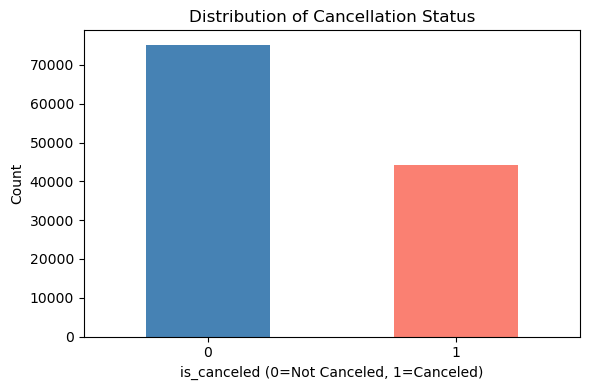

In [8]:
os.makedirs('../reports/figures', exist_ok=True)

# Cancellation count distribution (0 = Not Canceled, 1 = Canceled)
plt.figure(figsize=(6,4))
df['is_canceled'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Distribution of Cancellation Status')
plt.xlabel('is_canceled (0=Not Canceled, 1=Canceled)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_ratio.png')
plt.show()


> **Observation:**
> The cancellation rate is approximately **37%**, indicating that a significant proportion of bookings are canceled. This highlights the importance of developing a robust cancellation prediction model.

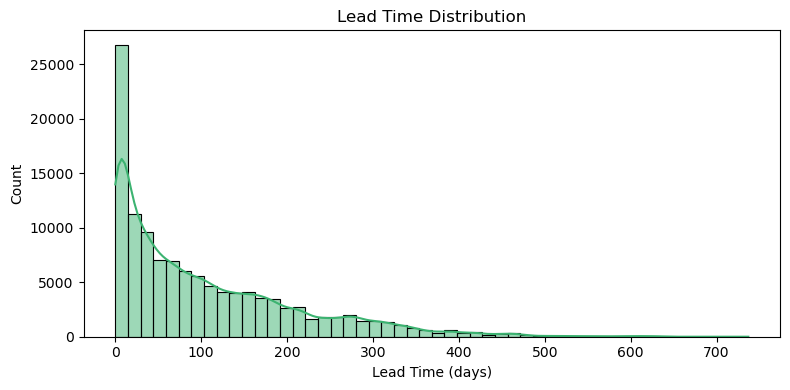

In [9]:
# Lead time distribution (days between booking and check-in)
plt.figure(figsize=(8,4))
sns.histplot(df['lead_time'], bins=50, kde=True, color='mediumseagreen')
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.tight_layout()
plt.savefig('../reports/figures/lead_time_distribution.png')
plt.show()


> **Observation:**
> Lead time shows a specific distribution that appears to be related to cancellation behavior. This suggests that the duration between the booking date and the arrival date could be a key predictor for potential cancellations.

In [17]:
# Outlier detection
# Check abnormal ADR values
print("Max ADR:", df['adr'].max())
print("ADR <= 0:", (df['adr'] <= 0).sum())

# Check bookings with no guests
zero_guests = df[(df['adults']==0) & (df['children']==0) & (df['babies']==0)]
print("Bookings with zero guests:", len(zero_guests))

# Check extreme lead time
print("Max lead time:", df['lead_time'].max(), "days")

Max ADR: 5400.0
ADR <= 0: 1960
Bookings with zero guests: 180
Max lead time: 737 days


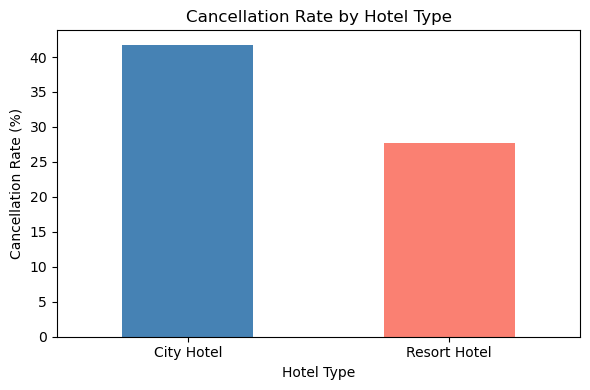

In [10]:
# Cancellation Rate by Hotel Type
plt.figure(figsize=(6,4))
hotel_cancel = df.groupby('hotel')['is_canceled'].mean() * 100
hotel_cancel.plot(kind='bar', color=['steelblue','salmon'])
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_by_hotel.png')
plt.show()


> **Observation:**
> The cancellation rate varies significantly depending on the **Hotel Type**. This indicates that guests' booking stability and cancellation patterns are influenced by the specific characteristics of City Hotels versus Resort Hotels.

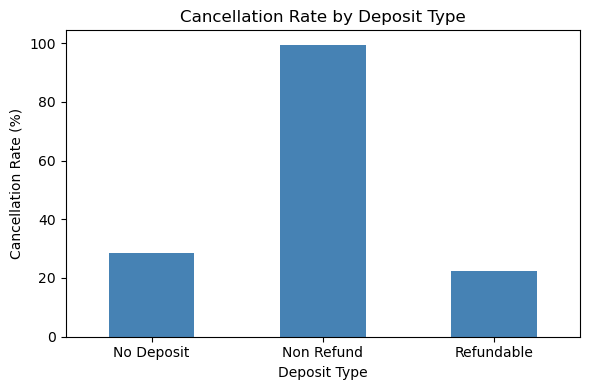

In [12]:
# Cancellation Rate by Deposit Type
plt.figure(figsize=(6,4))
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean() * 100
deposit_cancel.plot(kind='bar', color='steelblue')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_by_deposit.png')
plt.show()

> **Observation:**
> The cancellation rate shows a clear differentiation depending on the **Deposit Type**. This suggests that the deposit policy (e.g., Non-Refundable vs. No Deposit) significantly impacts a guest's commitment to their booking.

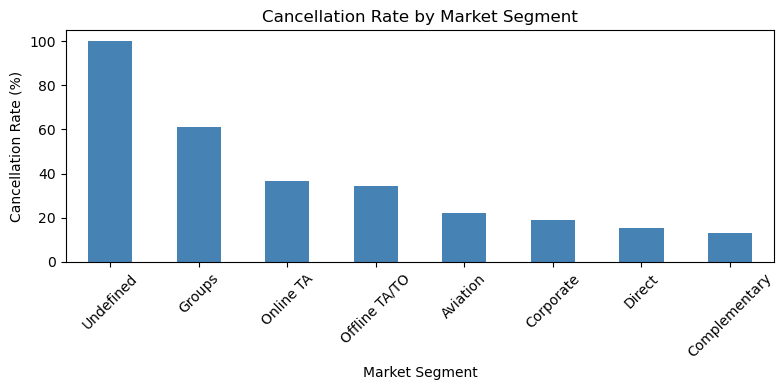

In [13]:
# Cancellation Rate by Market Segment
plt.figure(figsize=(8,4))
market_cancel = df.groupby('market_segment')['is_canceled'].mean() * 100
market_cancel.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_by_market.png')
plt.show()

> **Observation:**
> The cancellation rate varies significantly across different **Market Segments**. This suggests that booking stability is highly dependent on the distribution channel and customer segment, such as Online TAs versus Corporate bookings.

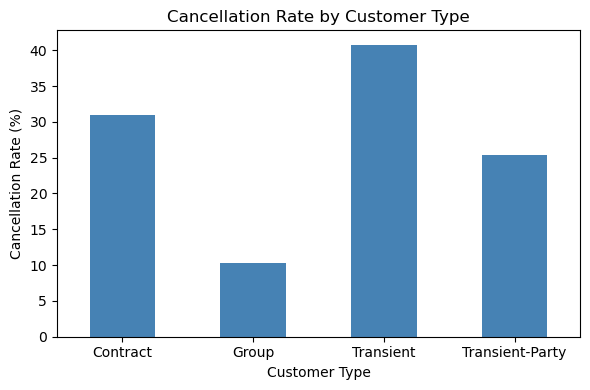

In [14]:
# Cancellation Rate by Customer Type
plt.figure(figsize=(6,4))
customer_cancel = df.groupby('customer_type')['is_canceled'].mean() * 100
customer_cancel.plot(kind='bar', color='steelblue')
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_by_customer.png')
plt.show()

> **Observation:**
> The cancellation rate differs significantly by **Customer Type**. Transient customers often show higher flexibility and higher cancellation rates, whereas Contract or Group bookings tend to have more stable reservation patterns.

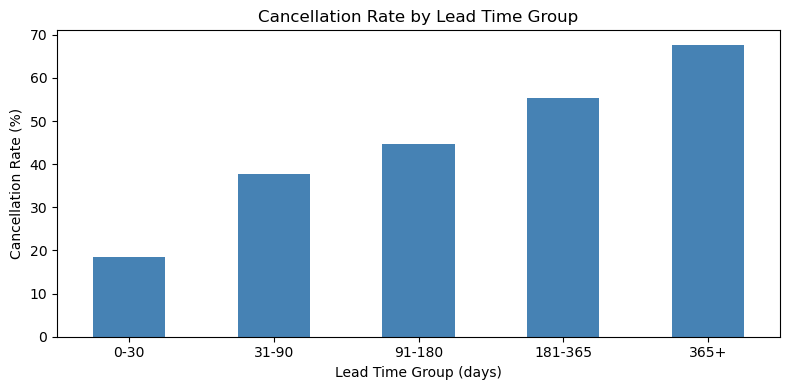

In [24]:
# Cancellation Rate by Lead Time Group
df['lead_time_group'] = pd.cut(df['lead_time'], bins=[-1, 30, 90, 180, 365, 737], 
                                labels=['0-30', '31-90', '91-180', '181-365', '365+'])
plt.figure(figsize=(8,4))
leadtime_cancel = df.groupby('lead_time_group', observed=False)['is_canceled'].mean() * 100
leadtime_cancel.plot(kind='bar', color='steelblue')
plt.title('Cancellation Rate by Lead Time Group')
plt.xlabel('Lead Time Group (days)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_by_leadtime.png')
plt.show()

> **Observation:**
> **Longer lead times** are strongly associated with higher cancellation rates. This suggests that as the window between the booking date and the arrival date increases, the likelihood of a change in travel plans also rises, leading to higher volatility in reservations.

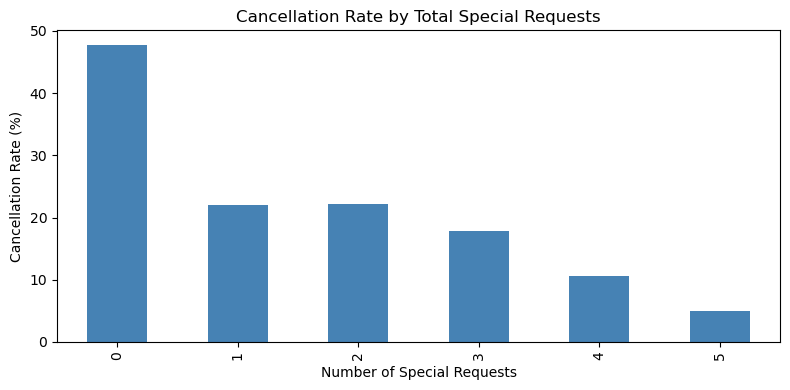

In [17]:
# Cancellation Rate by Total Special Requests
plt.figure(figsize=(8,4))

special_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean() * 100

special_cancel.plot(kind='bar', color='steelblue')

plt.title('Cancellation Rate by Total Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')

plt.tight_layout()

plt.savefig('../reports/figures/cancel_by_special_requests.png')

plt.show()

> **Observation:**
> Bookings with a higher number of **Special Requests** tend to have significantly lower cancellation rates. This suggests that guests who actively communicate their needs are more committed to their stay, reflecting higher customer engagement and a lower probability of "no-shows."

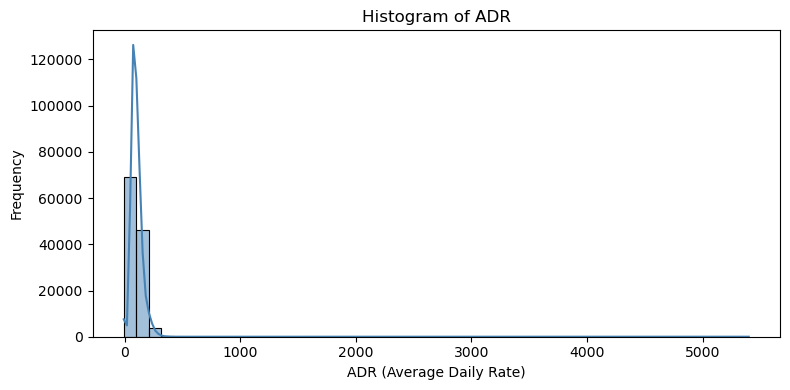

In [18]:
# Histogram of ADR
plt.figure(figsize=(8,4))

sns.histplot(df['adr'], bins=50, kde=True, color='steelblue')

plt.title('Histogram of ADR')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig('../reports/figures/adr_distribution.png')

plt.show()

> **Observation:**
> The **ADR (Average Daily Rate)** exhibits a strongly right-skewed distribution with several extreme high-value outliers. These outliers can distort the overall statistical analysis, justifying the need to filter the data (e.g., ADR < 500) to better understand the central tendency of hotel pricing.

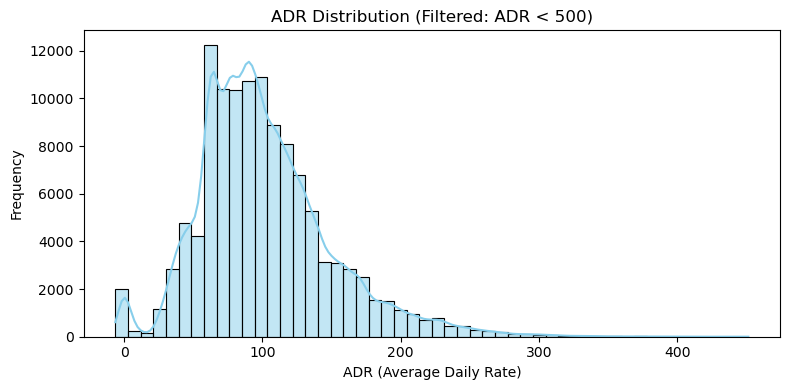

In [25]:
# Filtered ADR distribution to handle extreme outliers
plt.figure(figsize=(8,4))

# Visualizing ADR distribution for values under 500 to see central tendency
sns.histplot(df[df['adr'] < 500]['adr'], bins=50, kde=True, color='skyblue')

plt.title('ADR Distribution (Filtered: ADR < 500)')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/adr_distribution_filtered.png')
plt.show()

> **Observation:**
> After filtering for **ADR < 500**, the distribution shows a more localized concentration of hotel rates, primarily ranging between 50 and 150.For visualization only, non-positive ADR values and extreme high ADR values were excluded to better observe the main distribution. Most ADR values are concentrated in a much lower range than the maximum value.

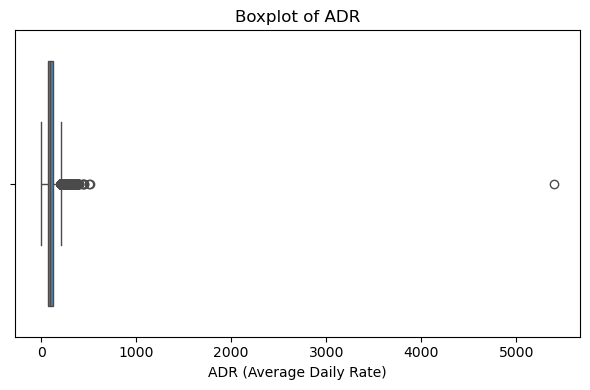

In [19]:
# ADR Boxplot - to visualize outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['adr'], color='steelblue')
plt.title('Boxplot of ADR')
plt.xlabel('ADR (Average Daily Rate)')
plt.tight_layout()
plt.savefig('../reports/figures/adr_boxplot.png')
plt.show()

> **Observation:**
> The ADR analysis reveals several **extreme outliers** that could potentially skew the results of our classification and regression models. These values must be addressed during the **data preprocessing** stage to ensure the reliability and predictive accuracy of our final AI models.

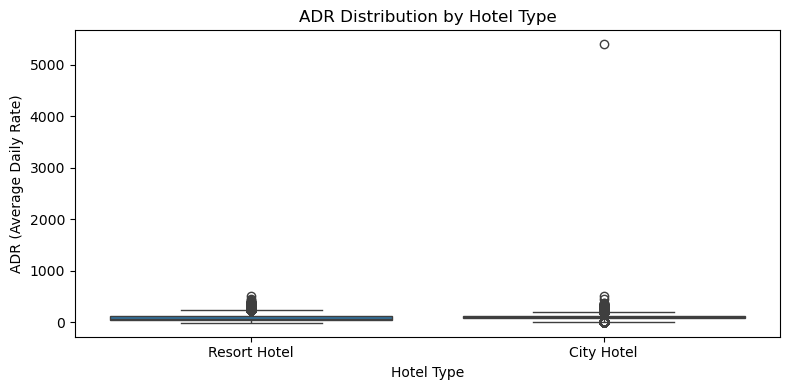

In [20]:
# ADR Distribution by Hotel Type
plt.figure(figsize=(8,4))
sns.boxplot(x='hotel', y='adr', data=df, hue='hotel', legend=False)
plt.title('ADR Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('ADR (Average Daily Rate)')
plt.tight_layout()
plt.savefig('../reports/figures/adr_by_hotel.png')
plt.show()

> **Observation:**
> The **ADR (Average Daily Rate)** exhibits a noticeable difference between **City Hotels** and **Resort Hotels**. This variation reflects the distinct pricing strategies and market demands associated with each hotel type, likely influenced by seasonal trends and guest demographics.

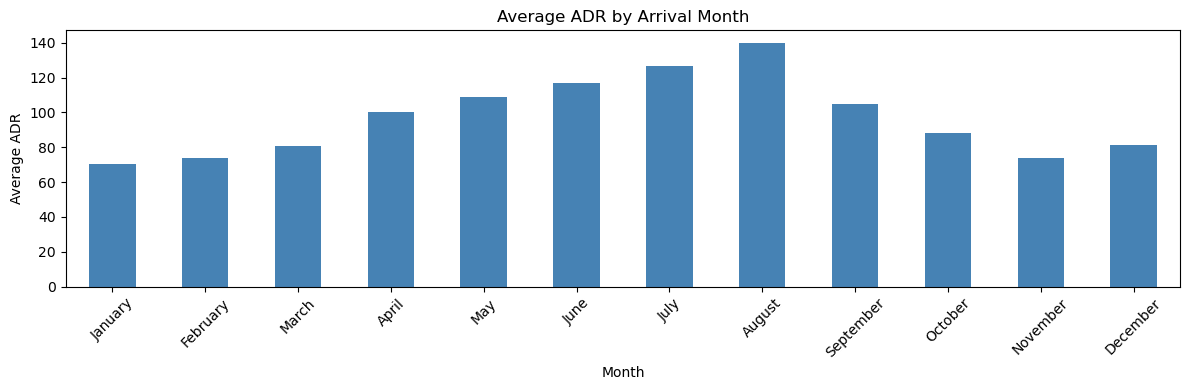

In [21]:
# Average ADR by Arrival Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12,4))
adr_by_month = df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)
adr_by_month.plot(kind='bar', color='steelblue')
plt.title('Average ADR by Arrival Month')
plt.xlabel('Month')
plt.ylabel('Average ADR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/adr_by_month.png')
plt.show()

> **Observation:**
> **ADR** tends to be significantly higher during the **summer months**, confirming clear **seasonal pricing patterns**. This peak reflects the high demand during the holiday season, which allows hotels to implement premium pricing strategies to maximize revenue.

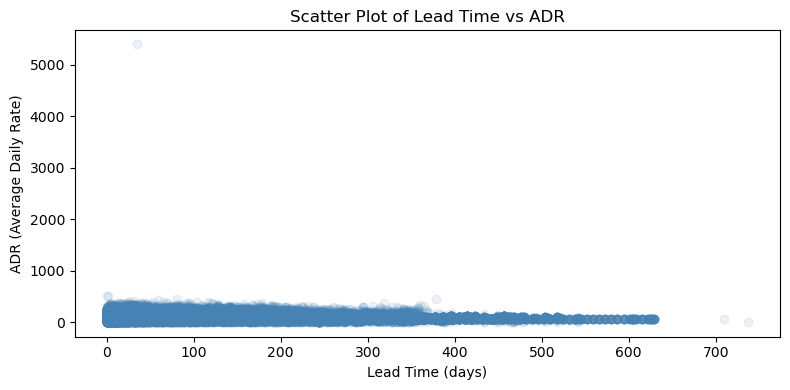

In [22]:
# Scatter Plot of Lead Time vs ADR
plt.figure(figsize=(8,4))
plt.scatter(df['lead_time'], df['adr'], alpha=0.1, color='steelblue')
plt.title('Scatter Plot of Lead Time vs ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('ADR (Average Daily Rate)')
plt.tight_layout()
plt.savefig('../reports/figures/leadtime_vs_adr.png')
plt.show()

> **Observation:**
> There is **no strong linear relationship** between **Lead Time** and **ADR**. This lack of correlation suggests that the time of booking does not directly dictate the pricing, and ADR is likely determined by more complex interactions between seasonality, market segments, and specific hotel policies.

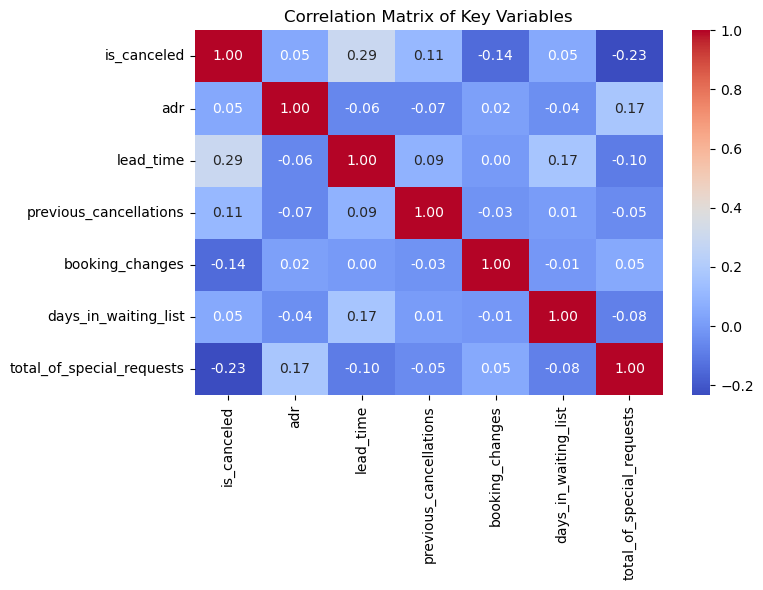

In [23]:
# Correlation Matrix of key variables
key_vars = ['is_canceled', 'adr', 'lead_time', 'previous_cancellations', 
            'booking_changes', 'days_in_waiting_list', 'total_of_special_requests']
plt.figure(figsize=(8,6))
sns.heatmap(df[key_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png')
plt.show()

> **Observation:**
> **Among the selected numerical variables, lead_time shows the strongest positive correlation with is_canceled. previous_cancellations also has a positive but weaker correlation. In contrast, total_of_special_requests shows a negative correlation with is_canceled, suggesting that bookings with more special requests may be less likely to be canceled.